# 🎬 Movie Recommendation System
## MovieLens Dataset
---

---
## Phase 1: Business Understanding
---


### 1.1 Business Context

The company intends to launch a video streaming platform to compete with established services such as Netflix, Amazon Prime, and Disney+. However, the company currently lacks content expertise — it does not know which movies to surface to which users, or how to personalise the viewing experience.

A key driver of revenue in streaming is **user retention**. Research consistently shows that personalised recommendations reduce churn and increase time-on-platform. Without a recommendation engine, new users face a blank or generic catalogue, which leads to early drop-off.

This project addresses that gap by building a **movie recommendation system** using the MovieLens dataset. The system will learn from user rating behaviour and surface the **top 5 personalised movie recommendations** for any given user.


### 1.2 Stakeholders

| Stakeholder | Interest | Impact |
|---|---|---|
| **Streaming Platform (Business)** | Increase user retention & revenue | High — primary beneficiary of the model |
| **End Users** | Discover movies they enjoy quickly | High — model quality directly affects their experience |
| **Movie Studios / Content Providers** | Surface their content to relevant audiences | Medium — better recommendations = more views |
| **Data / Engineering Teams** | Build and maintain the model pipeline | High — responsible for implementation |


### 1.3 Business Objectives (SMART)

| Dimension | Detail |
|---|---|
| **Specific** | Build a model that recommends the top 5 movies to a user based on their past ratings |
| **Measurable** | Achieve RMSE < 1.0 on the test set; NDCG@10 > 0.85 |
| **Achievable** | Using the MovieLens 100K dataset and established algorithms (SVD, KNN, TF-IDF) |
| **Relevant** | Directly supports user retention, which drives platform revenue |
| **Time-bound** | Deliver a working model, evaluation report, and Streamlit app by project deadline |


### 1.5 Success Criteria

| Criterion | Metric | Target |
|---|---|---|
| Rating Prediction Accuracy | RMSE | < 1.0 |
| Ranking Quality | NDCG@10 | > 0.85 |
| Cold-Start Coverage | % of new users served | 100% (content-based fallback) |
| User-Facing Delivery | Top-N recommendations returned | 5 per user |

**Why RMSE and NDCG?**
- **RMSE** measures how closely predicted ratings match actual ratings — useful for tuning the collaborative filter.
- **NDCG (Normalised Discounted Cumulative Gain)** measures the *ranking quality* of recommendations — it rewards placing the most relevant items at the top of the list, which is what users actually care about.


### 1.6 Project Plan (CRISP-DM Phases)

```
Phase 1: Business Understanding  ✅  (current)
Phase 2: Data Understanding      → EDA, distributions, missing values, rating patterns
Phase 3: Data Preparation        → Merging files, cleaning, feature engineering, train/test split
Phase 4: Modelling               → SVD, KNN (collaborative); TF-IDF (content-based); Hybrid
Phase 5: Evaluation              → RMSE, NDCG@10, comparison table
Phase 6: Deployment              → Streamlit app, Tableau story, non-technical slides
```

**Deliverables:**
- Jupyter Notebook (this file)
- GitHub Repository
- Tableau Story (EDA visualisations)
- Non-Technical Presentation (slides)
- Streamlit Deployment


---
## Phase 2: Data Understanding
---


### 2.1 Dataset Overview — MovieLens (Small, 100K)

The dataset is sourced from the **GroupLens Research Lab** at the University of Minnesota.  
It contains **100,836 ratings** applied to **9,742 movies** by **610 users** collected between 1996 and 2018.

The dataset ships as four CSV files:

| File | Rows (approx.) | Key Columns | Description |
|---|---|---|---|
| `ratings.csv` | 100,836 | `userId`, `movieId`, `rating`, `timestamp` | Core user–movie interactions |
| `movies.csv` | 9,742 | `movieId`, `title`, `genres` | Movie metadata |
| `tags.csv` | 3,683 | `userId`, `movieId`, `tag`, `timestamp` | Free-text user tags |
| `links.csv` | 9,742 | `movieId`, `imdbId`, `tmdbId` | External IDs for enrichment |


### 2.2 Import Libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import ndcg_score

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
sns.set_theme(style='whitegrid', palette='muted')

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully.")


Libraries loaded successfully.


### 2.3 Load Individual Files


In [2]:
# Load the four MovieLens CSV files

ratings = pd.read_csv('ratings.csv')
movies  = pd.read_csv('movies.csv')
tags    = pd.read_csv('tags.csv')
links   = pd.read_csv('links.csv')

print(f"ratings : {ratings.shape}")
print(f"movies  : {movies.shape}")
print(f"tags    : {tags.shape}")
print(f"links   : {links.shape}")


ratings : (100836, 4)
movies  : (9742, 3)
tags    : (3683, 4)
links   : (9742, 3)


### 2.4 Preview Each File


In [3]:
# ── ratings ───
print("=== ratings.csv ===")
display(ratings.head())
print(ratings.dtypes)
print()


=== ratings.csv ===


,userId,movieId,rating,timestamp
0,1,1,4.00,964982703
1,1,3,4.00,964981247
2,1,6,4.00,964982224
3,1,47,5.00,964983815
4,1,50,5.00,964982931


userId         int64
movieId        int64
rating       float64
timestamp      int64
dtype: object



In [4]:
# ── movies ───
print("=== movies.csv ===")
display(movies.head())
print(movies.dtypes)
print()


=== movies.csv ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


movieId     int64
title      object
genres     object
dtype: object



In [5]:
# ── tags ─
print("=== tags.csv ===")
display(tags.head())
print(tags.dtypes)
print()


=== tags.csv ===


,userId,movieId,tag,timestamp
0,2,60756,funny,1445714994
1,2,60756,Highly quotable,1445714996
2,2,60756,will ferrell,1445714992
3,2,89774,Boxing story,1445715207
4,2,89774,MMA,1445715200


userId        int64
movieId       int64
tag          object
timestamp     int64
dtype: object



In [6]:
# ── links ────────────────────────────────────────────────────────
print("=== links.csv ===")
display(links.head())
print(links.dtypes)


=== links.csv ===


,movieId,imdbId,tmdbId
0,1,114709,862.00
1,2,113497,8844.00
2,3,113228,15602.00
3,4,114885,31357.00
4,5,113041,11862.00


movieId      int64
imdbId       int64
tmdbId     float64
dtype: object


### 2.5 Descriptive Statistics


In [7]:
print("=== ratings — descriptive stats ===")
display(ratings.describe())

print("\n=== tags — descriptive stats ===")
display(tags.describe(include='all'))


=== ratings — descriptive stats ===


,userId,movieId,rating,timestamp
count,100836.00,100836.00,100836.00,100836.00
mean,326.13,19435.30,3.50,1205946087.37
std,182.62,35530.99,1.04,216261036.00
min,1.00,1.00,0.50,828124615.00
25%,177.00,1199.00,3.00,1019123866.00
50%,325.00,2991.00,3.50,1186086662.00
75%,477.00,8122.00,4.00,1435994144.50
max,610.00,193609.00,5.00,1537799250.00



=== tags — descriptive stats ===


,userId,movieId,tag,timestamp
count,3683.00,3683.00,3683,3683.00
unique,nan,nan,1589,nan
top,nan,nan,In Netflix queue,nan
freq,nan,nan,131,nan
mean,431.15,27252.01,NaN,1320031966.82
std,158.47,43490.56,NaN,172102450.44
min,2.00,1.00,NaN,1137179352.00
25%,424.00,1262.50,NaN,1137521216.00
50%,474.00,4454.00,NaN,1269832564.00
75%,477.00,39263.00,NaN,1498456765.50


### 2.6 Missing Value Audit


In [8]:
def missing_summary(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    result  = pd.DataFrame({'missing': missing, 'pct_%': pct})
    print(f"\n=== {name} ===")
    display(result[result['missing'] > 0] if result['missing'].sum() > 0
            else pd.DataFrame({'status': ['No missing values']}, index=[name]))

missing_summary(ratings, 'ratings')
missing_summary(movies,  'movies')
missing_summary(tags,    'tags')
missing_summary(links,   'links')



=== ratings ===


,status
ratings,No missing values



=== movies ===


,status
movies,No missing values



=== tags ===


,status
tags,No missing values



=== links ===


,missing,pct_%
tmdbId,8,0.08


### 2.7 Rating Distribution


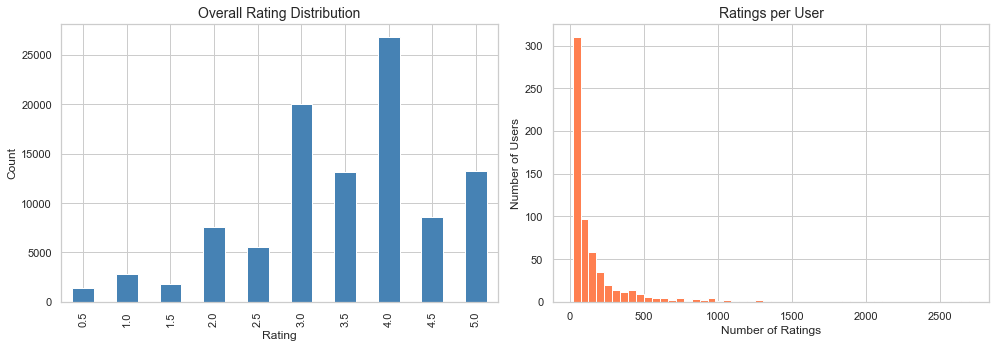


Rating scale  : 0.5 – 5.0
Mean rating   : 3.502
Median rating : 3.5
Unique users  : 610
Unique movies : 9724


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall rating distribution
ratings['rating'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Overall Rating Distribution', fontsize=14)
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

# Ratings per user
ratings_per_user = ratings.groupby('userId')['rating'].count()
axes[1].hist(ratings_per_user, bins=50, color='coral', edgecolor='white')
axes[1].set_title('Ratings per User', fontsize=14)
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

plt.tight_layout()
plt.show()

print(f"\nRating scale  : {ratings['rating'].min()} – {ratings['rating'].max()}")
print(f"Mean rating   : {ratings['rating'].mean():.3f}")
print(f"Median rating : {ratings['rating'].median():.1f}")
print(f"Unique users  : {ratings['userId'].nunique()}")
print(f"Unique movies : {ratings['movieId'].nunique()}")


### 2.8 Sparsity of the Ratings Matrix


In [10]:
n_users  = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)

sparsity = 1 - n_ratings / (n_users * n_movies)
print(f"Users         : {n_users}")
print(f"Movies        : {n_movies}")
print(f"Total ratings : {n_ratings}")
print(f"Matrix size   : {n_users} x {n_movies} = {n_users * n_movies:,}")
print(f"Sparsity      : {sparsity:.4%}")


Users         : 610
Movies        : 9724
Total ratings : 100836
Matrix size   : 610 x 9724 = 5,931,640
Sparsity      : 98.3000%


**Interpretation:** The ratings matrix is extremely sparse — most user–movie combinations have no rating. This is why collaborative filtering (and SVD in particular) is necessary; it can generalise from the observed ratings to predict missing ones.


### 2.9 Genre Distribution


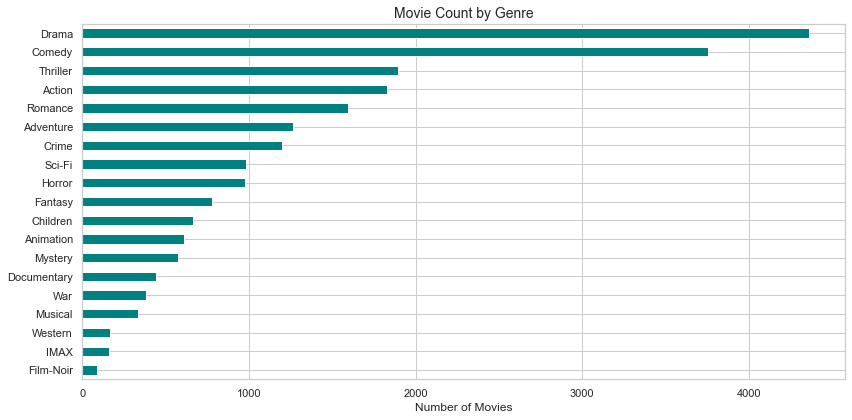

In [11]:
# Explode pipe-separated genres into individual rows
genre_series = movies['genres'].str.split('|').explode()
genre_counts = genre_series.value_counts().drop('(no genres listed)', errors='ignore')

plt.figure(figsize=(12, 6))
genre_counts.plot(kind='barh', color='teal', edgecolor='white')
plt.title('Movie Count by Genre', fontsize=14)
plt.xlabel('Number of Movies')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


### 2.10 Most-Rated and Highest-Rated Movies


In [12]:
# Most rated movies (popularity)
most_rated = (ratings.groupby('movieId')['rating']
                      .count()
                      .reset_index(name='n_ratings')
                      .merge(movies[['movieId','title']], on='movieId')
                      .sort_values('n_ratings', ascending=False)
                      .head(10))

print("Top 10 Most-Rated Movies:")
display(most_rated[['title','n_ratings']].reset_index(drop=True))

# Highest average rating (min 50 ratings to avoid noise)
best_rated = (ratings.groupby('movieId')['rating']
                      .agg(['mean','count'])
                      .reset_index()
                      .rename(columns={'mean':'avg_rating','count':'n_ratings'})
                      .query('n_ratings >= 50')
                      .merge(movies[['movieId','title']], on='movieId')
                      .sort_values('avg_rating', ascending=False)
                      .head(10))

print("\nTop 10 Highest-Rated Movies (min 50 ratings):")
display(best_rated[['title','avg_rating','n_ratings']].reset_index(drop=True))


Top 10 Most-Rated Movies:


,title,n_ratings
0,Forrest Gump (1994),329
1,"Shawshank Redemption, The (1994)",317
2,Pulp Fiction (1994),307
3,"Silence of the Lambs, The (1991)",279
4,"Matrix, The (1999)",278
5,Star Wars: Episode IV - A New Hope (1977),251
6,Jurassic Park (1993),238
7,Braveheart (1995),237
8,Terminator 2: Judgment Day (1991),224
9,Schindler's List (1993),220



Top 10 Highest-Rated Movies (min 50 ratings):


,title,avg_rating,n_ratings
0,"Shawshank Redemption, The (1994)",4.43,317
1,"Godfather, The (1972)",4.29,192
2,Fight Club (1999),4.27,218
3,Cool Hand Luke (1967),4.27,57
4,Dr. Strangelove or: How I Learned to Stop Worr...,4.27,97
5,Rear Window (1954),4.26,84
6,"Godfather: Part II, The (1974)",4.26,129
7,"Departed, The (2006)",4.25,107
8,Goodfellas (1990),4.25,126
9,Casablanca (1942),4.24,100


### 2.11 Tag Analysis


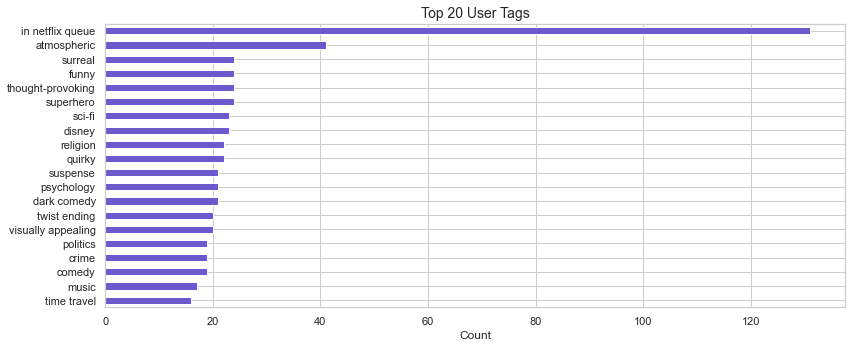

In [13]:
# Most common tags
top_tags = (tags['tag'].str.lower()
                       .value_counts()
                       .head(20))

plt.figure(figsize=(12, 5))
top_tags.plot(kind='barh', color='slateblue', edgecolor='white')
plt.title('Top 20 User Tags', fontsize=14)
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


---
## Phase 3: Data Preparation
---


### 3.1 Merge All Four Files

We build a single master DataFrame by joining all four files on their shared keys.  
The merge strategy is:

```
ratings  ──[movieId]──▶  movies
         ──[movieId]──▶  links
         ──[userId, movieId]──▶  tags  (aggregated first)
```


In [14]:
# ── Step 1: Aggregate tags per (userId, movieId) ─────────────────
# A movie can have multiple tags; collapse them into a single string
tags_agg = (tags.groupby(['userId', 'movieId'])['tag']
                 .apply(lambda x: ' '.join(x.str.lower().unique()))
                 .reset_index(name='tags'))

print(f"Aggregated tags shape: {tags_agg.shape}")
display(tags_agg.head())


Aggregated tags shape: (1775, 3)


,userId,movieId,tags
0,2,60756,funny highly quotable will ferrell
1,2,89774,boxing story mma tom hardy
2,2,106782,drugs leonardo dicaprio martin scorsese
3,7,48516,way too long
4,18,431,al pacino gangster mafia


In [15]:
# ── Step 2: Merge ratings + movies ──────────────────────────────
df = ratings.merge(movies, on='movieId', how='left')
print(f"After ratings + movies : {df.shape}")


After ratings + movies : (100836, 6)


In [16]:
# ── Step 3: Merge in links ──────────────────────────────────────
df = df.merge(links, on='movieId', how='left')
print(f"After + links          : {df.shape}")


After + links          : (100836, 8)


In [17]:
# ── Step 4: Merge in aggregated tags ────────────────────────────
df = df.merge(tags_agg, on=['userId', 'movieId'], how='left')
print(f"After + tags           : {df.shape}")

display(df.head())


After + tags           : (100836, 9)


,userId,movieId,rating,timestamp,title,genres,imdbId,tmdbId,tags
0,1,1,4.00,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,114709,862.00,NaN
1,1,3,4.00,964981247,Grumpier Old Men (1995),Comedy|Romance,113228,15602.00,NaN
2,1,6,4.00,964982224,Heat (1995),Action|Crime|Thriller,113277,949.00,NaN
3,1,47,5.00,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,114369,807.00,NaN
4,1,50,5.00,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,114814,629.00,NaN


### 3.2 Clean the Master DataFrame


In [18]:
# ── 3.2.1 Convert timestamp to datetime ─────────────────────────
df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
df = df.drop(columns=['timestamp'])

# ── 3.2.2 Extract year from title ───────────────────────────────
df['year'] = df['title'].str.extract(r'\((\d{4})\)').astype(float)

# ── 3.2.3 Normalise tags — fill NaN with empty string ───────────
df['tags'] = df['tags'].fillna('')

# ── 3.2.4 Check for duplicates ──────────────────────────────────
dupes = df.duplicated(subset=['userId','movieId']).sum()
print(f"Duplicate (userId, movieId) pairs: {dupes}")
if dupes > 0:
    df = df.drop_duplicates(subset=['userId','movieId'], keep='last')

# ── 3.2.5 Missing value check after merge ───────────────────────
print("\nMissing values in master df:")
display(df.isnull().sum()[df.isnull().sum() > 0])
print(f"\nFinal shape: {df.shape}")


Duplicate (userId, movieId) pairs: 0

Missing values in master df:


tmdbId    13
year      18
dtype: int64


Final shape: (100836, 10)


### 3.3 Feature Engineering


In [19]:
# ── Genre list column (for content-based filtering) ─────────────
df['genre_list'] = df['genres'].str.split('|')

# ── Combined text feature for TF-IDF ─────────────────────────────
# genres + tags concatenated; this will be the document for each movie
movie_text = (df.groupby('movieId')
                 .agg(genres=('genres', 'first'),
                      tags=('tags', lambda x: ' '.join(x.unique())))
                 .reset_index())
movie_text['content'] = movie_text['genres'].str.replace('|', ' ', regex=False) + ' ' + movie_text['tags']
movie_text = movie_text.merge(movies[['movieId','title']], on='movieId')

print("Movie content feature sample:")
display(movie_text[['title','content']].head())


Movie content feature sample:


,title,content
0,Toy Story (1995),Adventure Animation Children Comedy Fantasy p...
1,Jumanji (1995),Adventure Children Fantasy fantasy magic boar...
2,Grumpier Old Men (1995),Comedy Romance moldy old
3,Waiting to Exhale (1995),Comedy Drama Romance
4,Father of the Bride Part II (1995),Comedy pregnancy remake


### 3.4 Train / Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Simple random split for baseline; replace with temporal split if preferred
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Train size : {len(train_df):,} ({len(train_df)/len(df):.0%})")
print(f"Test size  : {len(test_df):,}  ({len(test_df)/len(df):.0%})")


Train size : 80,668 (80%)
Test size  : 20,168  (20%)


### 3.5 Prepare the Surprise Dataset (for Collaborative Filtering)

The `Surprise` library expects a specific dataset format built from the ratings file.


In [21]:
from surprise import Dataset, Reader

reader  = Reader(rating_scale=(ratings['rating'].min(), ratings['rating'].max()))
data    = Dataset.load_from_df(df[['userId', 'movieId', 'rating']], reader)

print("Surprise dataset created.")
print(f"Rating scale: {ratings['rating'].min()} – {ratings['rating'].max()}")


Surprise dataset created.
Rating scale: 0.5 – 5.0


### 3.6 Data Preparation Summary

| Step | Action | Output |
|---|---|---|
| File merge | ratings + movies + links + tags | Single master DataFrame |
| Timestamp | Convert Unix epoch → datetime | `datetime` column |
| Title cleaning | Extract year from title string | `year` column |
| Tag handling | Aggregate tags per (user, movie); fill NaN | `tags` column |
| Deduplication | Remove duplicate (userId, movieId) pairs | Clean DataFrame |
| Feature engineering | Genre list + combined content text | `genre_list`, `content` columns |
| Train/test split | 80 / 20 random split | `train_df`, `test_df` |
| Surprise format | Load ratings into Surprise `Dataset` | `data` object |

---
> ✅ **Data is clean and ready. Modelling begins in the next phase.**


---
## Next Steps: Phase 4 — Modelling

The modelling phase will implement:

1. **SVD** (Singular Value Decomposition) — collaborative filtering via matrix factorisation  
2. **KNN** (K-Nearest Neighbours) — memory-based collaborative filtering  
3. **TF-IDF + Cosine Similarity** — content-based filtering for cold-start users  
4. **Random Forest** — optional content-based baseline  
5. **Hybrid System** — combine best collaborative + best content-based model  
6. **Streamlit Deployment** — interactive app for top-5 recommendations


In [22]:
## SVD Model Implementation


### import necessary libraries


from surprise import SVD, accuracy
from surprise.model_selection import train_test_split

In [23]:
## split the data into training and testing sets

trainset, testset = train_test_split(data, test_size=0.3, random_state=42)

In [24]:
## Instantiate the SVD model
Svd_model = SVD(n_factors=50, random_state=42)

In [25]:
## fit the model
Svd_model.fit(trainset)

In [26]:
## predictions and evaluation  
predictions = Svd_model.test(testset)
print(accuracy.rmse(predictions))

RMSE: 0.8760
0.8759627174238854


In [27]:
## Hyperparameter Tuning

from surprise.model_selection import GridSearchCV

param_grid = {'n_factors': [20, 50],
                'n_epochs': [10, 25],
                'lr_all': [0.001, 0.005],
                'reg_all': [0.02, 0.07]}


In [28]:
grid_search = GridSearchCV(SVD, param_grid, measures=['rmse'], cv=8)
grid_search.fit(data)

In [29]:
print(grid_search.best_score['rmse'])
print(grid_search.best_params['rmse'])

0.8641996746128996
{'n_factors': 20, 'n_epochs': 25, 'lr_all': 0.005, 'reg_all': 0.02}


In [30]:
## Re-evaluate the best model on the test set
best_model = grid_search.best_estimator['rmse']
best_model.fit(trainset)

In [31]:
## Recommendation

def get_top_n(best_model,trainset,data,user_Id, n=10):
    # Get all movieIds
    all_movie_ids = set(data.df['movieId'].unique())
    
    # Get movies the user has already rated
    user_rated_movies = set(trainset.ur[trainset.to_inner_uid(user_Id)])
    
    # Predict ratings for all unrated movies
    predictions = []
    for movie_id in all_movie_ids:
        if movie_id not in user_rated_movies:
            pred = best_model.predict(user_Id, movie_id)
            predictions.append((movie_id, pred.est))
    
    # Sort predictions by estimated rating and return top n
    top_n = sorted(predictions, key=lambda x: x[1], reverse=True)[:n]
    return top_n
print(get_top_n(best_model,trainset,data, user_Id=1, n=5))

[(50, 5.0), (260, 5.0), (296, 5.0), (318, 5.0), (475, 5.0)]
